In [8]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects, fitGaussian2D
import os
import matplotlib.pyplot as plt
import referenceFrames as rf
import numpy as np
import math
from scipy import constants

In [9]:
sim = Simulation("BFE")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]
workDir = os.environ["PLATO_WORKDIR"]

sim["ObservingParameters/NumExposures"] = 1
dim = 9
sim["SubField/NumRows"] = dim
sim["SubField/NumColumns"] = dim
numSubPixels = sim["SubField/SubPixels"]

sim["CCD/IncludeBFE"] = "yes"

# One full-frame exposure

sim["CCD/IncludeConvolution"] = "no"
sim["PSF/Model"] = "MappedGaussian"

ccdCode = '2'
sim["CCD/Position"] = ccdCode

pixelSize = sim["CCD/PixelSize"] * constants.micro / constants.milli

ra, dec = rf.pixelToSkyCoordinates(sim, ccdCode, (dim) / 2, (dim) / 2)

ra = math.degrees(ra)
dec = math.degrees(dec)

starCatalogFilename = os.environ["PLATO_WORKDIR"] + "generatedFromPixelCoordinates.starcat"
sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename

sim["ControlHDF5Content/WriteSubPixelImages"] = True

sim["CCD/IncludeConvolution"] = "yes"
sim["PSF/Model"] = "MappedGaussian"

In [10]:
dim = dim * sim["SubField/SubPixels"]
sigma = sim["PSF/MappedGaussian/Sigma"]

In [11]:
magnitudes = np.arange(8, 20, 0.5)
widthWithBFE = np.array([])

for magnitude in magnitudes:
    
    myFile = open(starCatalogFilename, "w")
    myFile.write("# RA DEC Vmag starID\n")
    myFile.write("{0}  {1}  {2}  {3}\n".format(ra, dec, magnitude, 1))
    myFile.close()
    
    imageWithBFE = sim.run(removeOutputFile = True).getSubPixelImage(0)
    
    params = fitGaussian2D(imageWithBFE, np.max(imageWithBFE), dim / 2, dim / 2, sigma, sigma, subtractConstant = True)
    widthWithBFE = np.append(widthWithBFE, params[3] / numSubPixels)

Text(0, 0.5, '$\\sigma_{PSF}$')

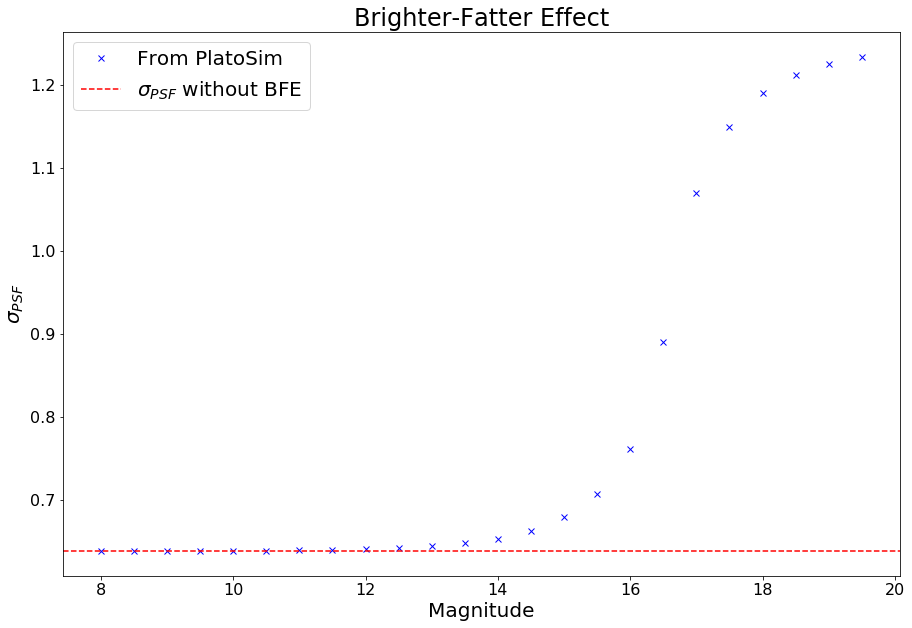

In [20]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.plot(magnitudes, widthWithBFE, "bx", label = "From PlatoSim")



################
# Expected value
################

plt.axhline(y = sigma, color = "r", linestyle = "--", label = "$\sigma_{PSF}$ without BFE")



########
# Layout
########

plt.title("Brighter-Fatter Effect", fontsize = 24)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Magnitude", fontsize = 20)
plt.ylabel("$\sigma_{PSF}$", fontsize = 20)
